# Séance 3 (Notebook C) : Tas binaire (Heap)

**Enseignant :** Jean Delpech

**Cours :** Algorithmie et développement dans l'ingénierie des données

**Classe :** M1 Data

**Année scolaire :** 2025/2026

**Dernière mise à jour :** juin 2026

---

## Objectifs

- Comprendre la propriété du tas et sa représentation en tableau
- Maîtriser les opérations fondamentales : insert, extract, heapify
- Comprendre Heapsort et le problème top-K
- Établir le lien entre tas binaire, files de priorité et schedulers de jobs

## Plan

| # | Bloc |
|---|---|
| 1 | Propriété du tas et représentation en tableau |
| 2 | Opérations fondamentales |
| 3 | `heapq` Python |
| 4 | Heapsort et problème top-K |
| 5 | Files de priorité et schedulers |

> **Notebooks complémentaires de cette séance**
> - **Notebook A** : Listes chaînées, Piles, Files, Récursion
> - **Notebook B** : Arbres binaires et BST


# PARTIE 1 : Propriété du tas et représentation en tableau

## 1.1 Définition

Un **tas binaire** (binary heap) est un arbre binaire **complet** qui respecte une invariante sur chaque nœud.

Un arbre binaire complet est un arbre où tous les niveaux sont remplis sauf éventuellement le dernier, qui se remplit de gauche à droite. Cette propriété de complétude est ce qui permet la représentation en tableau.

Il existe deux variantes selon l'invariante choisie :

- **Max-heap** : chaque nœud est **supérieur ou égal** à ses enfants → la racine contient le maximum
- **Min-heap** : chaque nœud est **inférieur ou égal** à ses enfants → la racine contient le minimum

```
        Max-heap             Min-heap
           90                   5
          /  \                 /  \
        70    80             10    8
       /  \  /  \           /  \ /  \
      40  60 50  20        30  20 15  12
```

> **Attention :** la propriété du tas est plus faible que celle du BST. Dans un BST, tout le sous-arbre gauche est inférieur à la racine. Dans un max-heap, seuls les enfants directs sont inférieurs, un nœud du niveau 2 peut très bien être plus grand qu'un nœud du niveau 1 s'ils ne sont pas en relation parent/enfant directe. Le tas n'est donc **pas adapté à la recherche** d'une valeur arbitraire.

## 1.2 Représentation en tableau

C'est la particularité centrale du tas : grâce à la propriété de complétude, on peut stocker l'arbre dans un **tableau sans aucun pointeur**. On numérote les nœuds niveau par niveau, de gauche à droite, en commençant à l'indice 0.

```
Arbre :          90
                /  \
              70    80
             /  \  /  \
            40  60 50  20

Tableau : [ 90, 70, 80, 40, 60, 50, 20 ]
index   :    0   1   2   3   4   5   6
```

Les relations parent/enfant se calculent arithmétiquement, aucun pointeur n’est nécessaire :

| Relation | Formule |
|---|---|
| Parent de i | `(i - 1) // 2` |
| Enfant gauche de i | `2 * i + 1` |
| Enfant droit de i | `2 * i + 2` |

C'est pour cette raison que le tas est en pratique **plus efficace en mémoire** qu'un BST : pas d'objet nœud, pas de références, juste un tableau Python.


In [1]:
# Vérification des formules d'indexation sur le tableau exemple

def parent(i: int) -> int:
    return (i - 1) // 2

def left_child(i: int) -> int:
    return 2 * i + 1

def right_child(i: int) -> int:
    return 2 * i + 2

heap = [90, 70, 80, 40, 60, 50, 20]

print("Tableau :", heap)
print()
print(f"Parent de 70  (indice 1) : heap[{parent(1)}] = {heap[parent(1)]}")
print(f"Parent de 40  (indice 3) : heap[{parent(3)}] = {heap[parent(3)]}")
print(f"Enfant gauche de 90 (i=0): heap[{left_child(0)}] = {heap[left_child(0)]}")
print(f"Enfant droit  de 90 (i=0): heap[{right_child(0)}] = {heap[right_child(0)]}")
print(f"Enfant gauche de 70 (i=1): heap[{left_child(1)}] = {heap[left_child(1)]}")
print()

# Vérification de la propriété max-heap
def is_max_heap(data: list) -> bool:
    n = len(data)
    for i in range(1, n):
        if data[i] > data[parent(i)]:
            return False
    return True

print(f"Tableau respecte la propriété max-heap : {is_max_heap(heap)}")
print(f"Tableau trié [1,2,3,4,5] est un max-heap ? {is_max_heap([1,2,3,4,5])}")


Tableau : [90, 70, 80, 40, 60, 50, 20]

Parent de 70  (indice 1) : heap[0] = 90
Parent de 40  (indice 3) : heap[1] = 70
Enfant gauche de 90 (i=0): heap[1] = 70
Enfant droit  de 90 (i=0): heap[2] = 80
Enfant gauche de 70 (i=1): heap[3] = 40

Tableau respecte la propriété max-heap : True
Tableau trié [1,2,3,4,5] est un max-heap ? False


# PARTIE 2 : Opérations fondamentales

## 2.1 Les deux mouvements de base

Toutes les opérations du tas reposent sur deux mouvements élémentaires qui **restaurent la propriété du tas** après une modification :

**Sift-up** (remonter) : utilisé après une **insertion**. On ajoute le nouveau nœud à la fin du tableau (dernière position du dernier niveau), puis on le fait remonter en l'échangeant avec son parent tant qu'il est plus grand que lui.

```
Insertion de 95 dans le max-heap :

Étape 1 - ajout en fin :
[ 90, 70, 80, 40, 60, 50, 20, 95 ]
                               ↑ position 7, parent = position 3 (valeur 40)

              90
            /    \
          70      80
         /  \    /  \
        40  60  50  20
       /
     *95*              ← nœud ajouté, parent = 40


Étape 2 - 95 > 40 → échange :
[ 90, 70, 80, 95, 60, 50, 20, 40 ]
                ↑ position 3, parent = position 1 (valeur 70)

              90
            /    \
          70      80
         /  \    /  \
       *95* 60  50  20
       /
       40              ← 40 est descendu


Étape 3 - 95 > 70 → échange :
[ 90, 95, 80, 70, 60, 50, 20, 40 ]
     ↑ position 1, parent = position 0 (valeur 90)

              90
            /    \
         *95*     80
         /  \    /  \
        70  60  50  20
       /
       40

Étape 4 - 95 > 90 → échange :
[ 95, 90, 80, 70, 60, 50, 20, 40 ]
  ↑ position 0 = racine → terminé

            *95*
            /    \
          90      80
         /  \    /  \
        70  60  50  20
       /
       40              ← propriété max-heap restaurée
```

**Sift-down** (descendre) : utilisé après une **extraction**. On extrait la racine (le maximum), on la remplace par le dernier élément du tableau, puis on fait descendre cet élément en l'échangeant avec le plus grand de ses enfants tant qu'il est plus petit qu'eux.

## 2.2 Complexités

| Opération | Complexité | Principe |
|---|---|---|
| `peek` (liste le maximum sans le retirer)| O(1) | La racine, qui est toujours le maxiumu, est toujours en `heap[0]` |
| `insert` (ajouter une nouvelle valeur) | O(log n) | Insérer = mettre à la fin et faire un sift-up qui remonte au plus h niveaux (h=log2(n) sur un arbre complet|
| `extract_max` (retirer et retourner le maximum)| O(log n) | La racine est toujours le maximum. On ne peut la retirer sans laisser un trou dans le tableau. L’opération est complexe : on interverti la racine avec le dernier élément, on retire la racine qui est maintenant à la fin (plus de trou) et on sift-down l’élément promu pour le descendre au plus de h niveaux (et h=log2(n), toujours)|
| Construction depuis un tableau | O(n) | Heapify bottom-up |

La construction en O(n) (au lieu de O(n log n) si on insérait un à un) est un résultat contre-intuitif important : en partant des nœuds internes les plus bas et en appliquant sift-down vers le haut, la plupart des nœuds n'ont que peu de niveaux à descendre.

L’implémentation des opérations `peek`, `_sift_up`, `extract_max` ne pose aucun problème particulier, il suffit de réaliser les mouvements/échanges vus précédemment.


In [ ]:
class MaxHeap:
    """Max-heap implémenté en tableau. La racine contient toujours le maximum."""

    def __init__(self):
        self._data: list = []

    def __len__(self) -> int:
        return len(self._data)

    def peek(self):
        """Retourne le maximum sans le retirer. O(1)."""
        if not self._data:
            raise IndexError("heap vide")
        return self._data[0]

    # ── Insertion ─────────────────────────────────────────────────

    def insert(self, value) -> None:
        """Insère une valeur et restaure la propriété. O(log n)."""
        self._data.append(value)          # ajout en fin
        self._sift_up(len(self._data) - 1)

    def _sift_up(self, i: int) -> None:
        """Fait remonter l'élément à l'indice i jusqu'à sa position correcte."""
        while i > 0:
            p = (i - 1) // 2             # indice du parent
            if self._data[i] > self._data[p]:
                self._data[i], self._data[p] = self._data[p], self._data[i]
                i = p                    # continuer depuis la nouvelle position
            else:
                break                    # propriété restaurée

    # ── Extraction ────────────────────────────────────────────────

    def extract_max(self):
        """Retire et retourne le maximum. O(log n)."""
        if not self._data:
            raise IndexError("heap vide")
        # Échanger la racine avec le dernier élément
        self._data[0], self._data[-1] = self._data[-1], self._data[0]
        maximum = self._data.pop()       # retirer l'ancien maximum (maintenant en fin)
        if self._data:
            self._sift_down(0)           # restaurer la propriété depuis la racine
        return maximum

    def _sift_down(self, i: int) -> None:
        """Fait descendre l'élément à l'indice i jusqu'à sa position correcte."""
        n = len(self._data)
        while True:
            largest = i
            left    = 2 * i + 1
            right   = 2 * i + 2
            # Trouver le plus grand parmi le nœud et ses enfants
            if left  < n and self._data[left]  > self._data[largest]:
                largest = left
            if right < n and self._data[right] > self._data[largest]:
                largest = right
            if largest == i:
                break                    # le nœud est déjà le plus grand → terminé
            self._data[i], self._data[largest] = self._data[largest], self._data[i]
            i = largest                  # continuer depuis la nouvelle position

    # ── Construction depuis un tableau existant ───────────────────

    @classmethod
    def from_list(cls, data: list) -> "MaxHeap":
        """Construit un heap depuis un tableau en O(n) - heapify bottom-up."""
        h = cls()
        h._data = list(data)
        n = len(h._data)
        # Partir du dernier nœud interne et remonter
        for i in range((n - 2) // 2, -1, -1):
            h._sift_down(i)
        return h

    def __repr__(self):
        return f"MaxHeap({self._data})"


# ── Démonstration ─────────────────────────────────────────────────
h = MaxHeap()
for v in [40, 70, 20, 90, 60, 80, 50]:
    h.insert(v)

print(f"Heap après insertions : {h}")
print(f"Maximum (peek)        : {h.peek()}")
print(f"Extract max           : {h.extract_max()}")
print(f"Heap après extraction : {h}")

# Construction depuis une liste
h2 = MaxHeap.from_list([40, 70, 20, 90, 60, 80, 50])
print(f"\nHeap from_list        : {h2}")


## 2.3 Exercice : Vérifier la propriété du tas

> Écrire une fonction `is_valid_max_heap(data)` qui vérifie que le tableau `data` respecte la propriété max-heap.
> (Retenez-vous de retourner voir l’implémentation montrée ci-dessus.)  
> Pour chaque nœud interne d'indice i, vérifier que ses enfants (s'ils existent) sont bien inférieurs ou égaux.  
> Complexité attendue : O(n).


In [ ]:
def is_valid_max_heap(data: list) -> bool:
    """Vérifie que le tableau respecte la propriété max-heap."""
    # TODO
    pass


# ── Tests ─────────────────────────────────────────────────────────
print(is_valid_max_heap([90, 70, 80, 40, 60, 50, 20]))   # True
print(is_valid_max_heap([90, 70, 80, 40, 95, 50, 20]))   # False : 95 > 70 son parent
print(is_valid_max_heap([]))                              # True (vide)
print(is_valid_max_heap([42]))                            # True (un seul élément)


# PARTIE 3 : `heapq` Python : le min-heap standard

Python fournit le module `heapq` qui implémente un **min-heap** directement sur une liste Python ordinaire. Il ne s’agit pas d’une classe dédiée, juste des fonctions qui opèrent sur une liste existante.

```python
import heapq

h = []
heapq.heappush(h, valeur)    # insertion - O(log n)
heapq.heappop(h)             # extraction du minimum - O(log n)
h[0]                         # peek - O(1), sans extraction
heapq.heapify(h)             # construction in-place depuis une liste - O(n)
heapq.nlargest(k, iterable)  # top-k plus grands - O(n log k)
heapq.nsmallest(k, iterable) # top-k plus petits - O(n log k)
```

> **Min-heap uniquement.** Pour simuler un max-heap avec `heapq`, la convention est d'insérer les valeurs avec le signe « moins » `-` devant : `heappush(h, -valeur)` puis `-heappop(h)`. Ainsi le plus grand entier devient le plus petit en valeur absolue négative, et heapq l'extrait en premier.

`heapq` est la structure à utiliser en pratique dans un contexte Python. Notre `MaxHeap` from scratch servait à comprendre le mécanisme interne. `heapq` est ce qu'on utilisera pour Heapsort, top-K et Dijkstra (séance 4).


In [2]:
import heapq

# Min-heap standard
h = []
for v in [40, 80, 20, 90, 50, 70, 30]:
    heapq.heappush(h, v)

print(f"Heap (min en tête) : {h}")
print(f"Minimum (peek)     : {h[0]}")
print(f"Extract min        : {heapq.heappop(h)}")
print(f"Heap après extract : {h}")

# Simuler un max-heap avec des valeurs négées
print("\n--- Simulation max-heap ---")
hmax = []
for v in [40, 80, 20, 90, 50]:
    heapq.heappush(hmax, -v)

print(f"Tableau interne (négatifs) : {hmax}")
print(f"Maximum récupéré           : {-heapq.heappop(hmax)}")

# heapify : construction O(n) depuis une liste existante
data = [40, 80, 20, 90, 50, 70, 30]
heapq.heapify(data)
print(f"\nheapify in-place : {data}")


Heap (min en tête) : [20, 50, 30, 90, 80, 70, 40]
Minimum (peek)     : 20
Extract min        : 20
Heap après extract : [30, 50, 40, 90, 80, 70]

--- Simulation max-heap ---
Tableau interne (négatifs) : [-90, -80, -20, -40, -50]
Maximum récupéré           : 90

heapify in-place : [20, 50, 30, 90, 80, 70, 40]


# PARTIE 4 : Heapsort et problème Top-K

## 4.1 Heapsort

**Heapsort** trie un tableau en deux phases en exploitant la propriété du tas :

**Phase 1 : construction du tas** : transformer le tableau en max-heap en O(n) (heapify bottom-up).

**Phase 2 : extraction successive** : extraire le maximum n fois. À chaque extraction, le maximum va en fin de tableau (la portion déjà triée grandit d'un élément) et on applique sift-down sur la portion restante.

```
Tableau initial : [40, 70, 20, 90, 60, 80, 50]

Après heapify  : [90, 70, 80, 40, 60, 20, 50]   ← max-heap

Extraction 1   : échange heap[0]↔heap[6], sift-down sur [0..5]
               : [80, 70, 50, 40, 60, 20 | 90]

Extraction 2   : échange heap[0]↔heap[5], sift-down sur [0..4]
               : [70, 60, 50, 40, 20 | 80, 90]

...            : [20, 40, 50, 60, 70, 80, 90]  ← trié ✓
```

**Complexité :** O(n log n) dans tous les cas, y compris sur des données déjà triées, contrairement à Quicksort qui dégénère en O(n²). En espace : O(1) le tri se fait en place, aucun tableau auxiliaire nécessaire.

**Limite :** en pratique Heapsort est moins rapide que Quicksort sur des données aléatoires à cause de sa mauvaise localité du cache car les accès au tableau sautent beaucoup, ce qui est pénalisé par le cache CPU. Python utilise Timsort (hybride Mergesort + Insertion Sort) qui est stable et plus rapide en pratique.

## 4.2 Problème Top-K

**Problème :** étant donné un flux de n éléments, trouver les k plus grands sans trier l'ensemble.

**Approche naïve :** trier tout le tableau et prendre les k derniers, la complexité est en O(n log n) (sans compter que cela contrevient à la consigne).

**Approche heap :** maintenir un **min-heap de taille k**. Pour chaque nouvel élément :
- Si le heap contient moins de k éléments → insérer
- Sinon, si l'élément est plus grand que le minimum du heap → remplacer le minimum (qui, dans un min-heap, est placé à l’indice 0, c’est-à-dire en tête)

À la fin, le heap contient exactement les k plus grands éléments. Complexité : **O(n log k)**, bien meilleur que O(n log n) à condition que k << n (bien penser à la progression de la fonction log).

```
k = 3, flux = [4, 1, 7, 2, 9, 3, 8, 5, 6]

- 4 → heap vide, on insère : [4]
- 1 → moins de 3 éléments, on insère : [1, 4], le min-heap place le plus petit en tête
- 7 → moins de 3 éléments, on insère : [1, 4, 7], le min-heap plein désormais
- 2 → 2 < heap[0]=1 → ignoré : [1, 4, 7]
- 9 → 9 > heap[0]=1 → on remplace 1 par 9 puis sift-down : [4, 9, 7]
- 3 → 3 < heap[0]=4 → ignoré : [4, 9, 7]
- 8 → 8 > heap[0]=4 → on remplace 4 par 8 puis sift-down : [7, 9, 8]
- 5 → 5 < heap[0]=7 → ignoré : [7, 9, 8]
- 6 → 6 < heap[0]=7 → ignoré : [7, 9, 8]
Résultat final : {7, 8, 9} (on a bien sélectionné les 3 plus grands)
```

Avec le module `heapq` l’implémentation est également assez immédiate (il faut utiliser `heapreplace()`).

À titre d’exercice vous pouvez essayer d’implémenter un `heapsort()` et un `_sift_down()` from scratch. (optionnel)

In [ ]:
# Exercice : Votre code pour heapsort et sift_down



In [3]:
import heapq
import random
import timeit
import matplotlib.pyplot as plt

# ── Top-K avec min-heap ────────────────────────────────────────────

def top_k(data: list, k: int) -> list:
    """Retourne les k plus grands éléments. O(n log k)."""
    heap = []
    for x in data:
        if len(heap) < k:
            heapq.heappush(heap, x)
        elif x > heap[0]:           # plus grand que le minimum du heap
            heapq.heapreplace(heap, x)
    return sorted(heap, reverse=True)


# ── Démonstration ─────────────────────────────────────────────────
data = [40, 70, 20, 90, 60, 80, 50, 30, 10]
print(f"Données    : {data}")
print(f"Heapsort   : {heapsort(data)}")
print(f"Top-3      : {top_k(data, 3)}")
print(f"Vérif      : {sorted(data, reverse=True)[:3]}")


Données    : [40, 70, 20, 90, 60, 80, 50, 30, 10]
Heapsort   : [10, 20, 30, 40, 50, 60, 70, 80, 90]
Top-3      : [90, 80, 70]
Vérif      : [90, 80, 70]


La figure ci-dessous compare un tri de base (`sorted()`) avec un tri heap. On voit que la différence se joue surtout quand k est petit par rapport au nombre d’éléments (log(k) vs log(n))

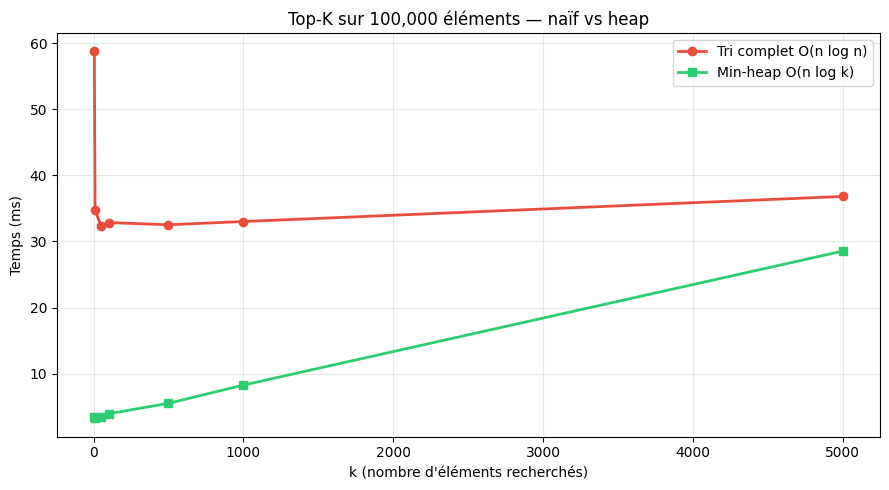


Pour k=5    : naïf 58.77ms  vs  heap 3.45ms
Pour k=1000 : naïf 32.53ms  vs  heap 5.54ms

Les deux méthodes se rejoignent quand k ≈ n (trier tout revient au même).


In [4]:
# Benchmark : naïf O(n log n) vs heap O(n log k)
import timeit, random, math
import matplotlib.pyplot as plt

n      = 100_000
ks     = [5, 10, 50, 100, 500, 1_000, 5_000]
data   = [random.random() for _ in range(n)]

times_naive = []
times_heap  = []

for k in ks:
    t_naive = timeit.timeit(lambda: sorted(data, reverse=True)[:k], number=20) / 20 * 1000
    t_heap  = timeit.timeit(lambda: heapq.nlargest(k, data),        number=20) / 20 * 1000
    times_naive.append(t_naive)
    times_heap.append(t_heap)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ks, times_naive, 'o-', color='#e74c3c', linewidth=2, label='Tri complet O(n log n)')
ax.plot(ks, times_heap,  's-', color='#2ecc71', linewidth=2, label='Min-heap O(n log k)')
ax.set_xlabel('k (nombre d\'éléments recherchés)')
ax.set_ylabel('Temps (ms)')
ax.set_title(f'Top-K sur {n:,} éléments - naïf vs heap')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nPour k=5    : naïf {times_naive[0]:.2f}ms  vs  heap {times_heap[0]:.2f}ms")
print(f"Pour k=1000 : naïf {times_naive[-3]:.2f}ms  vs  heap {times_heap[-3]:.2f}ms")
print(f"\nLes deux méthodes se rejoignent quand k ≈ n (trier tout revient au même).")


# Conclusion

## Réflexe à développer

> Dès qu'un problème demande de **répéter l'extraction du minimum ou du maximum** parmi un ensemble dynamique (qui reçoit des insertions en cours de route), la réponse est presque toujours un tas. Si c'est un ensemble statique et qu'on veut juste le top-K une fois, `heapq.nlargest` suffit.


## Pour aller plus loin : Mini-mémoire

*Ces éléments ne sont pas traités dans ce notebook. Ils constituent des pistes d'approfondissement pour les étudiants qui travaillent sur un mini-mémoire en lien avec cette séance, ou qui cherchent à appronfondir le sujet.*

- **Sujet 5 : Dijkstra et A***. Implémentation complète de Dijkstra avec `heapq` sur un réseau routier OSMnx, extension A* avec heuristique Haversine, comparaison du nombre de nœuds explorés
- **Sujet 6 : Tri avancé et Map/Reduce**. Tri externe sur un fichier 500 Mo, fusion de k fichiers triés avec `heapq.merge`, lien avec le paradigme Map/Reduce distribué
- **Médiane en flux** : maintenir la médiane courante d'un flux en O(log n) par élément avec deux heaps (un max-heap pour la moitié inférieure, un min-heap pour la moitié supérieure)
- **Codage de Huffman** : algorithme de compression sans perte qui construit un arbre de codage optimal en extrayant itérativement les deux nœuds de plus faible fréquence d'un min-heap


# PARTIE 5 : Files de priorité et schedulers

## 5.1 File de priorité

Une **file de priorité** est une structure abstraite qui garantit que l'élément extrait est toujours celui de **priorité maximale** (ou minimale) parmi ceux présents, indépendamment de l'ordre d'insertion. 
Ici on parle de priorité en faisant référence à la valeur des éléments. On affectera à cette valeur un sens en matière de priorité (par exemple : une échelle de 1 à 3 où 1 sera la priorité maximale, dans ce cas il faudra traiter la valeur minimum, mais on pourrait aussi bien manipuler des valeurs de 1 à 10 avec 10 la priorité maximum, et dans ce cas traiter la valeur maximum.

C'est exactement ce que réalise un tas : `extract_min` sur un min-heap est l'implémentation naturelle d'une file de priorité qui va chercher la valeur minimum (si on adopte la convention priorité max = 1).

Ce n’est plus l’ordre d’arrivée qui compte. D’ailleurs de deux évènements avec la même priorité, les heaps ne « sauront » pas les départager, même si l’un est arrivé avant l’autre (faire attention à ça si c’est un besoin métier).

La différence avec une file FIFO classique (vue dans le Notebook A) :

| | File FIFO | File de priorité |
|---|---|---|
| Ordre d'extraction | Ordre d'arrivée | Priorité de l'élément |
| Structure interne | `deque` | Tas binaire |
| `enqueue` / `push` | O(1) | O(log n) |
| `dequeue` / `pop` | O(1) | O(log n) |
| Cas d'usage | Kafka, BFS | Schedulers, Dijkstra |

## 5.2 Lien avec les schedulers de jobs

Un scheduler de jobs doit en permanence choisir quel job exécuter en priorité parmi une file d'attente : jobs urgents, jobs CPU-intensifs, jobs en retard. À chaque décision, il extrait le job de plus haute priorité et peut en recevoir de nouveaux à tout moment.

Ce pattern, extraction du minimum/maximum + insertions dynamiques, est le cas d'usage canonique du tas. Les schedulers des systèmes d'exploitation (ordonnancement de processus), les moteurs de workflow (Airflow, Prefect) et les algorithmes de plus court chemin (Dijkstra, séance 4) reposent tous sur ce même mécanisme.

## 5.3 Lien avec Dijkstra (aperçu séance 4)

L'algorithme de Dijkstra explore les nœuds d'un graphe **dans l'ordre croissant de leur distance estimée** depuis la source. À chaque étape il extrait le nœud le moins coûteux, met à jour les distances de ses voisins, et les réinsère dans la file. C'est un usage direct du min-heap :

```python
# Squelette de Dijkstra avec heapq (détaillé en séance 4)
import heapq

priority_queue = [(0, source)]        # (distance, nœud)
while priority_queue:
    dist, node = heapq.heappop(priority_queue)    # nœud le plus proche
    for neighbor, weight in graph[node]:
        new_dist = dist + weight
        heapq.heappush(priority_queue, (new_dist, neighbor))
```

La complexité de Dijkstra est O((V + E) log V). Le log V vient précisément des opérations sur le heap.

Voilà une simulation de file de priorité traitée par min-heap :


In [5]:
import heapq
import time
import random
from dataclasses import dataclass, field

# ── Simulation d'un scheduler de jobs ─────────────────────────────

@dataclass(order=True)
class Job:
    """Un job avec une priorité (1 = urgent, 3 = normal)."""
    priority:   int
    job_id:     int   = field(compare=False)
    name:       str   = field(compare=False)
    duration_s: float = field(compare=False)

    def __str__(self):
        levels = {1: 'URGENT', 2: 'NORMAL', 3: 'DIFFÉRÉ'}
        return f"[{levels[self.priority]}] Job#{self.job_id} '{self.name}' ({self.duration_s:.1f}s)"


# File de priorité = min-heap sur (priority, job_id, ...)
scheduler: list = []
job_counter = 0

def submit(name: str, priority: int, duration: float):
    """Soumet un job dans le scheduler."""
    global job_counter
    job = Job(priority=priority, job_id=job_counter, name=name, duration_s=duration)
    heapq.heappush(scheduler, job)
    job_counter += 1
    print(f"  → Soumis  : {job}")

def execute_next():
    """Exécute le job de plus haute priorité."""
    if not scheduler:
        print("  → File vide.")
        return
    job = heapq.heappop(scheduler)
    print(f"  ← Exécuté : {job}  |  {len(scheduler)} jobs restants")

# Soumission dans un ordre quelconque
print("=== Soumission des jobs ===")
submit("backup_quotidien",    priority=3, duration=120.0)
submit("alerte_cpu_critique", priority=1, duration=2.0)
submit("export_rapport",      priority=2, duration=15.0)
submit("purge_logs",          priority=3, duration=45.0)
submit("restart_service",     priority=1, duration=3.0)
submit("sync_donnees",        priority=2, duration=30.0)

print(f"\n=== Exécution par priorité ({len(scheduler)} jobs en attente) ===")
while scheduler:
    execute_next()


=== Soumission des jobs ===
  → Soumis  : [DIFFÉRÉ] Job#0 'backup_quotidien' (120.0s)
  → Soumis  : [URGENT] Job#1 'alerte_cpu_critique' (2.0s)
  → Soumis  : [NORMAL] Job#2 'export_rapport' (15.0s)
  → Soumis  : [DIFFÉRÉ] Job#3 'purge_logs' (45.0s)
  → Soumis  : [URGENT] Job#4 'restart_service' (3.0s)
  → Soumis  : [NORMAL] Job#5 'sync_donnees' (30.0s)

=== Exécution par priorité (6 jobs en attente) ===
  ← Exécuté : [URGENT] Job#1 'alerte_cpu_critique' (2.0s)  |  5 jobs restants
  ← Exécuté : [URGENT] Job#4 'restart_service' (3.0s)  |  4 jobs restants
  ← Exécuté : [NORMAL] Job#2 'export_rapport' (15.0s)  |  3 jobs restants
  ← Exécuté : [NORMAL] Job#5 'sync_donnees' (30.0s)  |  2 jobs restants
  ← Exécuté : [DIFFÉRÉ] Job#3 'purge_logs' (45.0s)  |  1 jobs restants
  ← Exécuté : [DIFFÉRÉ] Job#0 'backup_quotidien' (120.0s)  |  0 jobs restants
